In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import matplotlib.pyplot as plt

In [18]:
from pic0rick.ndt_acquisition import UltrasonicAcquisition

In [19]:
PATH = "../docs/data/calibration_block_5steps_1018steel.h5" # change this to your own file
PIEZOID = "Pink 5MHz"                                       # change this to your own description


# Testing acquisitions and testing gain

In [20]:
THICKNESS = 0.010 # [m] thickness of the calibration block, used to estimate where the echo should be and to calibrate the acquisition parameters.

for gain in (0, 10, 20, 30, 40, 50):
    a = UltrasonicAcquisition.from_probe(
        piezo_id= PIEZOID,
        Fech=60e6, gain=gain*10,
        pon=70, poff=70, damp=6000,
        target="Calibration 1018 steel block, ~" + str(THICKNESS * 1000) + "mm",
        h5_path=PATH
    )


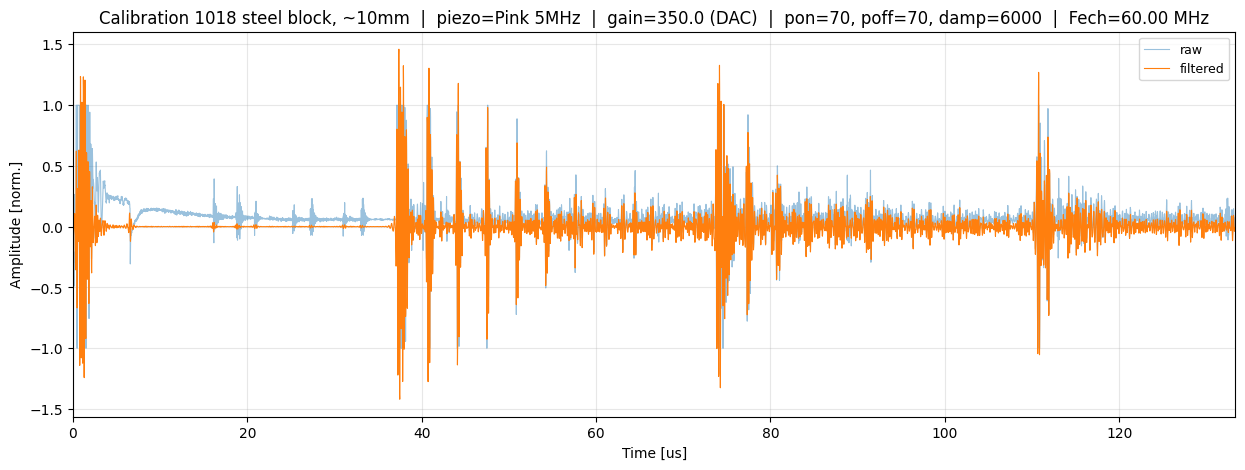

In [21]:
a = UltrasonicAcquisition.from_probe(
        Fech=60e6, gain=350,                            # Fech is 60Msps, gain values can be from 0 to 500
        piezo_central_freq=5e6,
        piezo_bandwidth=4e6,
        piezo_id= PIEZOID,
        pon=70, poff=70, damp=6000,                     # Pulse parameters, can be tuned to optimize the signal for a given target.
        target="Calibration 1018 steel block, ~10mm",   # Target description, will be saved in the h5 file and can be used to identify the acquisition later.
        h5_path=PATH,                                   # Where data is saved
        overwrite = False                               # If acquisition with these parameters already exists in the h5 file, 
                                                        # it will be loaded instead of acquired again.
    )
a.plot();

[37.416666666666664, 40.81666666666666, 44.166666666666664, 47.53333333333333, 50.949999999999996, 54.3]


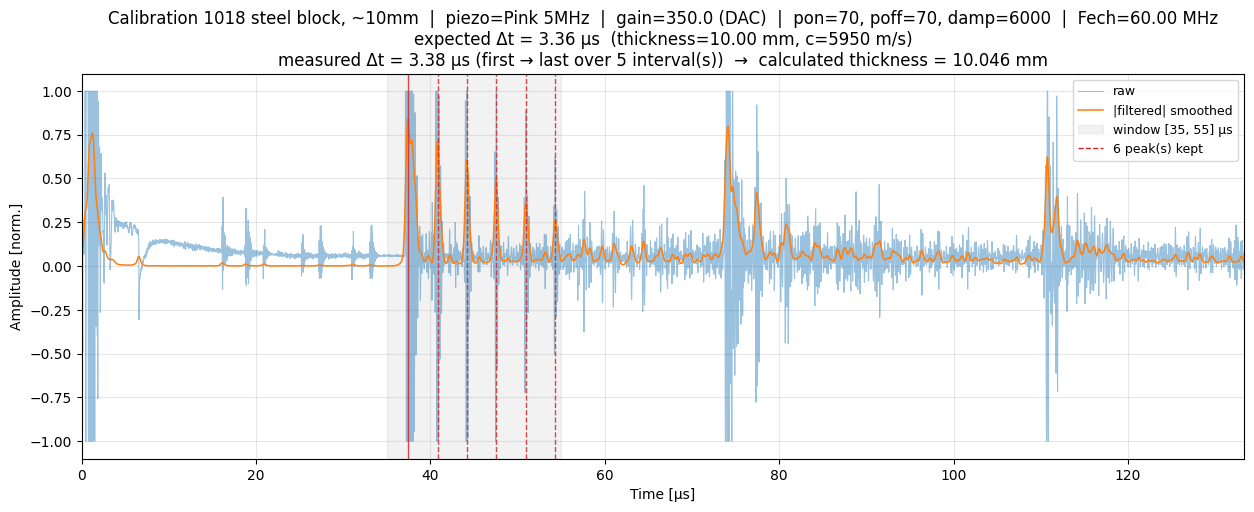

In [22]:
result = a.detect_echoes(
    start_us=35, end_us=55,     # window where the main echo is expected
    target_thickness=THICKNESS,    # [m]
    speed_of_sound=5950,       # [m/s]  longitudinal in steel
    smooth=15,
    smooth_kernel=7,
)
print(result["peak_times_us"])

## Calibration of best pulse value

optimal pon=poff = 95


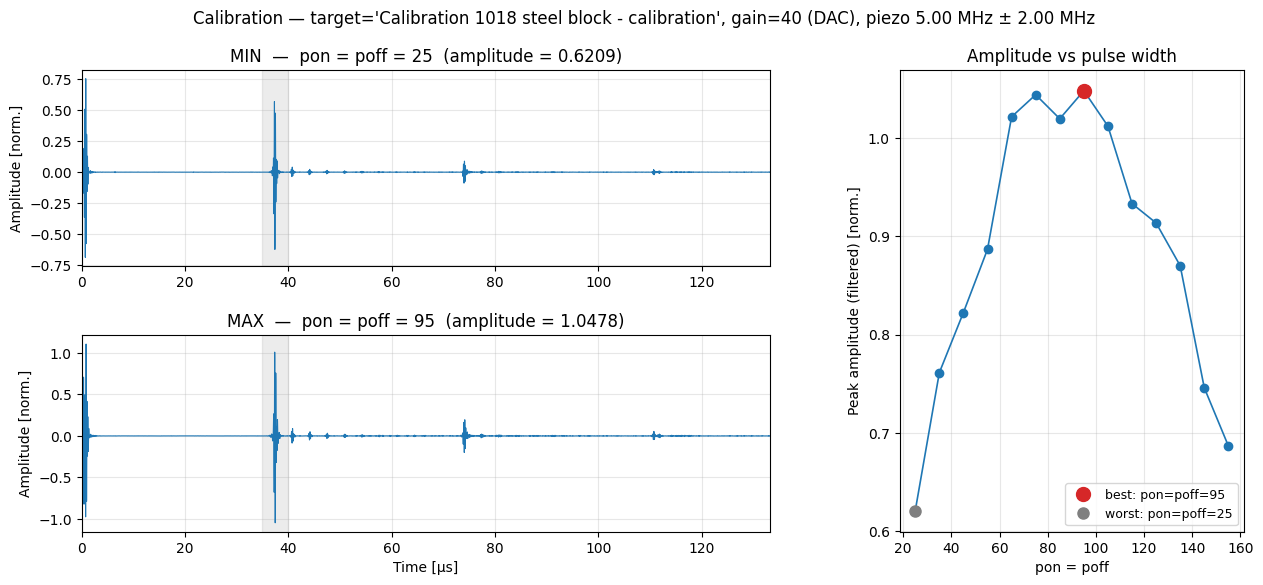

In [23]:
calib = UltrasonicAcquisition.calibrate(
    PATH,
    Fech=60e6,
    start_us=35, end_us=40,        # echo of interest window
    gain=40,
    piezo_central_freq=5e6,
    piezo_bandwidth=4e6,
    piezo_id=PIEZOID,
    target="Calibration 1018 steel block - calibration",
    overwrite=False,
)
print("optimal pon=poff =", calib["best_pon_poff"])

## 10mm

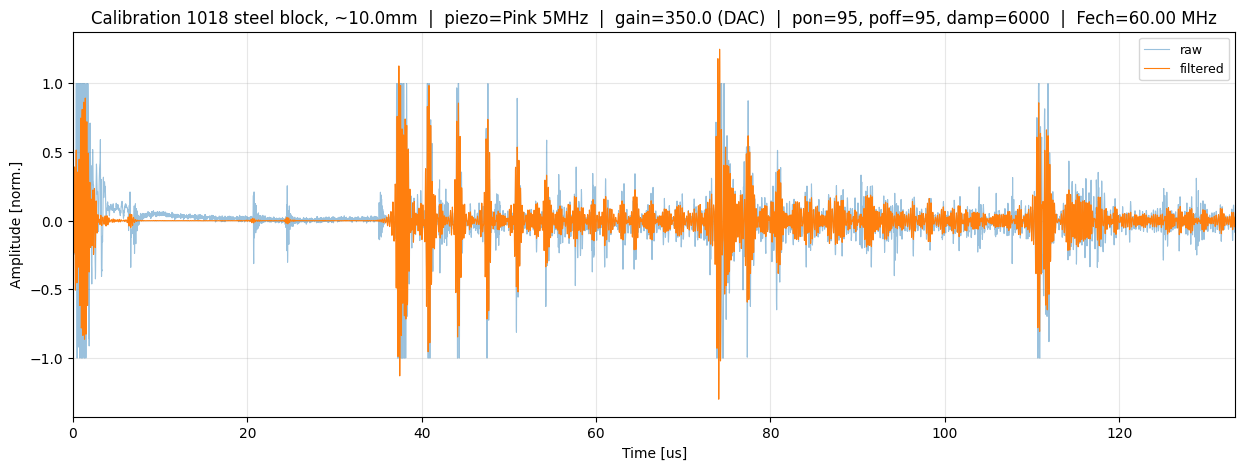

In [24]:
THICKNESS = 0.010 # [m] thickness of the calibration block, used to estimate where the echo should be and to calibrate the acquisition parameters.
a = UltrasonicAcquisition.from_probe(
        Fech=60e6, gain=350,                            # Fech is 60Msps, gain values can be from 0 to 500
        piezo_central_freq=5e6,
        piezo_bandwidth=2e6,
        piezo_id= PIEZOID,
        pon=calib["best_pon_poff"], 
        poff=calib["best_pon_poff"], 
        damp=6000,                                      # Pulse parameters, can be tuned to optimize the signal for a given target.
        target="Calibration 1018 steel block, ~" + str(THICKNESS * 1000) + "mm",   # Target description, will be saved in the h5 file and can be used to identify the acquisition later.
        h5_path=PATH,                                   # Where data is saved
        overwrite = False                               # If acquisition with these parameters already exists in the h5 file, 
                                                        # it will be loaded instead of acquired again.
    )
a.plot();

[37.45, 40.800000000000004, 44.18333333333334, 47.55, 50.96666666666667, 54.3, 57.61666666666667]


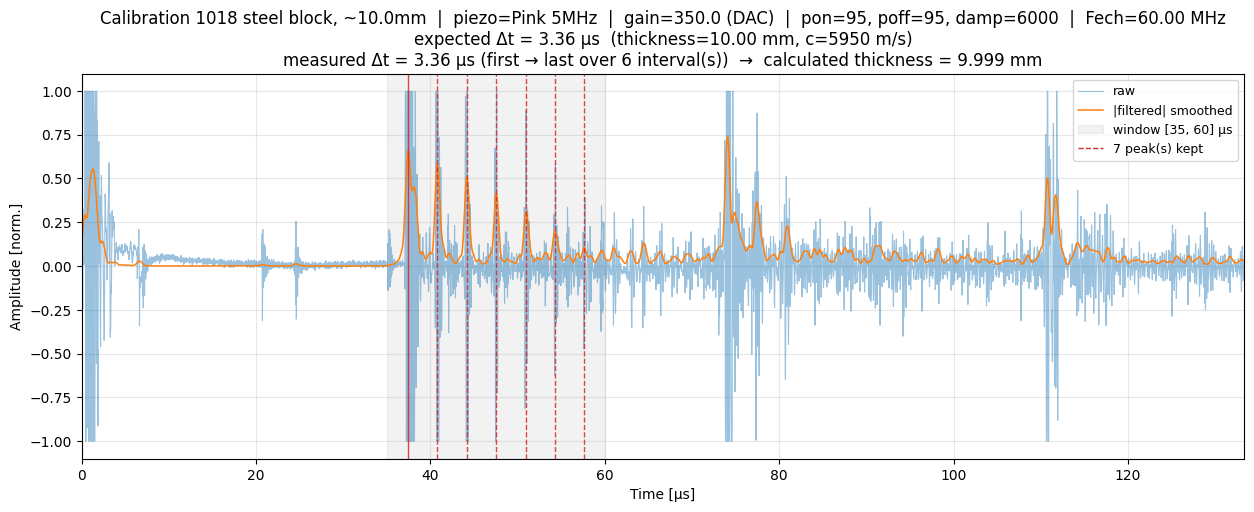

In [25]:
result = a.detect_echoes(
    start_us=35, end_us=60,     # window where the main echo is expected
    target_thickness=THICKNESS,    # [m]
    speed_of_sound=5950,       # [m/s]  longitudinal in steel
    smooth=15,
    smooth_kernel=7,
)
print(result["peak_times_us"])

## 15mm

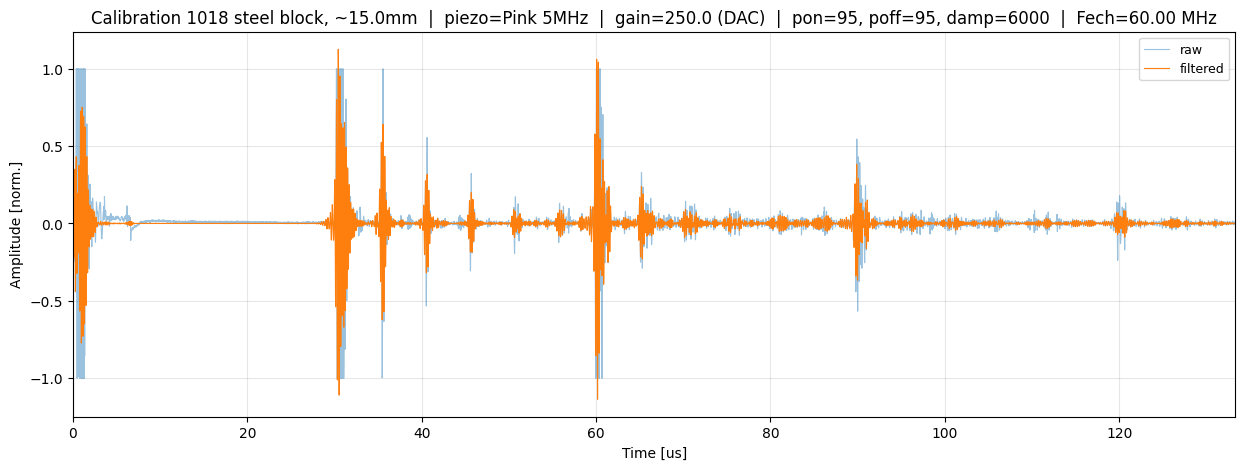

In [26]:
THICKNESS = 0.015 # [m] thickness of the calibration block, used to estimate where the echo should be and to calibrate the acquisition parameters.
a = UltrasonicAcquisition.from_probe(
        Fech=60e6, gain=250,                            # Fech is 60Msps, gain values can be from 0 to 500
        piezo_central_freq=5e6,
        piezo_bandwidth=2e6,
        piezo_id= PIEZOID,
        pon=calib["best_pon_poff"], 
        poff=calib["best_pon_poff"], 
        damp=6000,                                      # Pulse parameters, can be tuned to optimize the signal for a given target.
        target="Calibration 1018 steel block, ~" + str(THICKNESS * 1000) + "mm",   # Target description, will be saved in the h5 file and can be used to identify the acquisition later.
        h5_path=PATH,                                   # Where data is saved
        overwrite = False                               # If acquisition with these parameters already exists in the h5 file, 
                                                        # it will be loaded instead of acquired again.
    )
a.plot();

[30.483333333333334, 35.53333333333333, 40.583333333333336, 45.7]


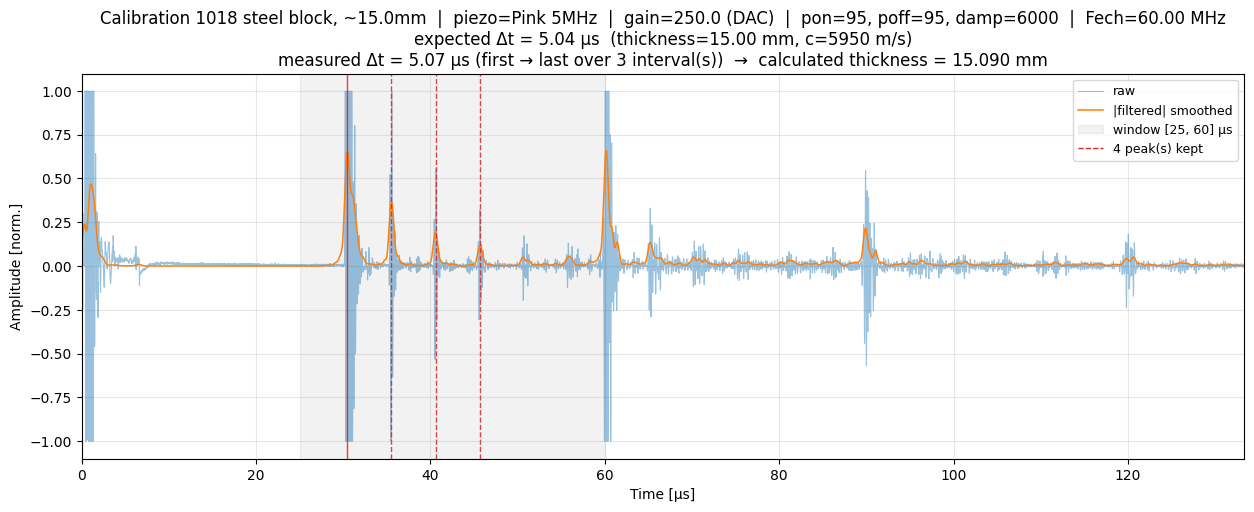

In [27]:
result = a.detect_echoes(
    start_us=25, end_us=60,     # window where the main echo is expected
    target_thickness=THICKNESS,    # [m]
    speed_of_sound=5950,       # [m/s]  longitudinal in steel
    smooth=15,
    smooth_kernel=7,
)
print(result["peak_times_us"])

## 25mm

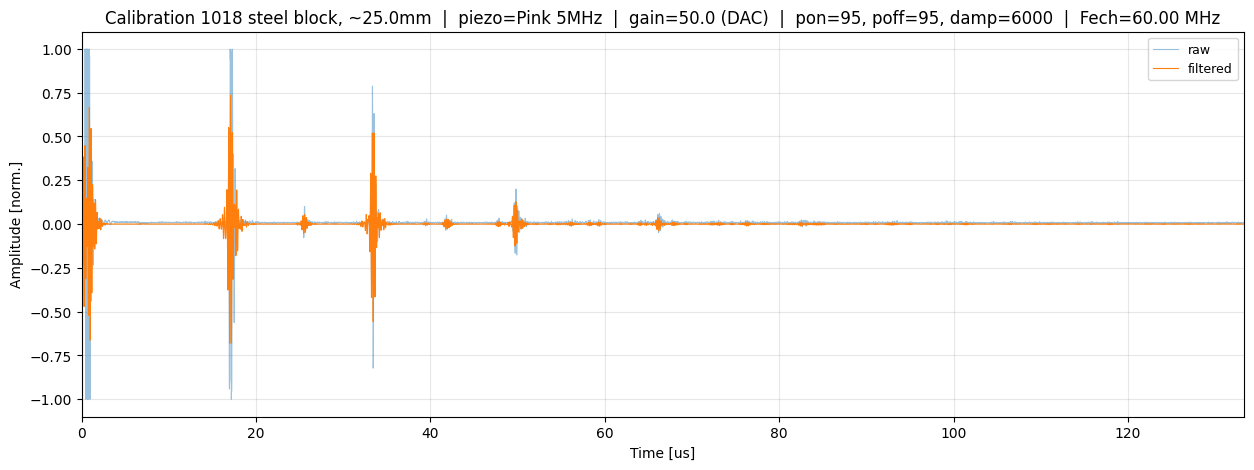

In [28]:
THICKNESS = 0.025 # [m] thickness of the calibration block, used to estimate where the echo should be and to calibrate the acquisition parameters.
a = UltrasonicAcquisition.from_probe(
        Fech=60e6, gain=50,                            # Fech is 60Msps, gain values can be from 0 to 500
        piezo_central_freq=5e6,
        piezo_bandwidth=2e6,
        piezo_id= PIEZOID,
        pon=calib["best_pon_poff"], 
        poff=calib["best_pon_poff"], 
        damp=6000,                                      # Pulse parameters, can be tuned to optimize the signal for a given target.
        target="Calibration 1018 steel block, ~" + str(THICKNESS * 1000) + "mm",   # Target description, will be saved in the h5 file and can be used to identify the acquisition later.
        h5_path=PATH,                                   # Where data is saved
        overwrite = False                               # If acquisition with these parameters already exists in the h5 file, 
                                                        # it will be loaded instead of acquired again.
    )
a.plot();

[17.066666666666666, 33.43333333333333, 49.75]


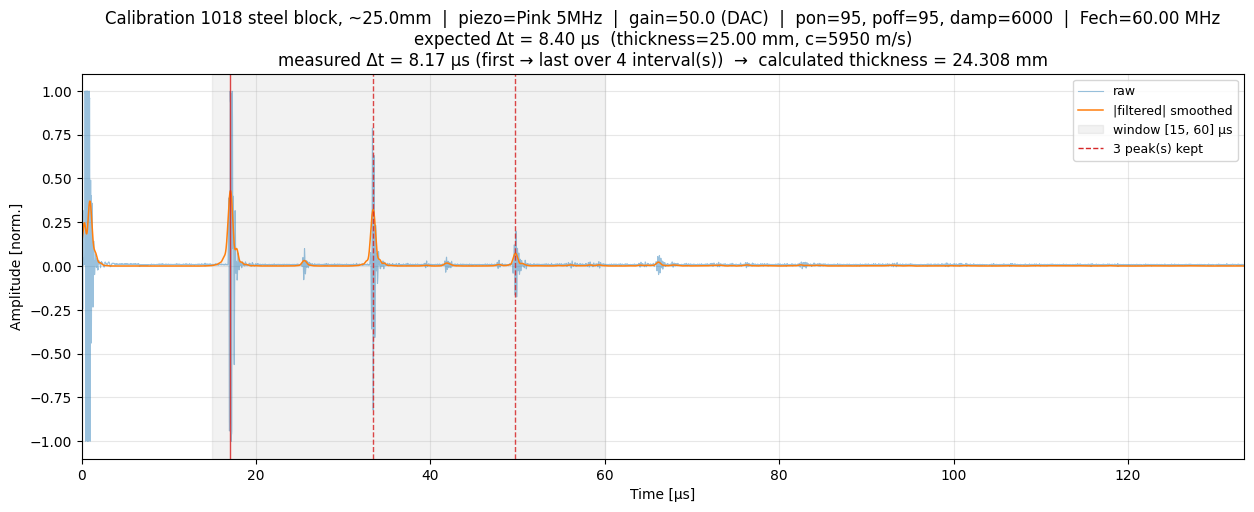

In [29]:
result = a.detect_echoes(
    start_us=15, end_us=60,     # window where the main echo is expected
    target_thickness=THICKNESS,    # [m]
    speed_of_sound=5950,       # [m/s]  longitudinal in steel
    smooth=15,
    smooth_kernel=7,
)
print(result["peak_times_us"])

# Checking what lives in the file

In [30]:
acq_data = UltrasonicAcquisition.info(PATH, verbose = False)
acq_data

{'h5_path': '../docs/data/calibration_block_5steps_1018steel.h5',
 'n_signals': 28,
 'gains': [0.0,
  40.0,
  50.0,
  100.0,
  150.0,
  200.0,
  250.0,
  300.0,
  350.0,
  400.0,
  500.0],
 'targets': ['Calibration 1018 steel block - calibration',
  'Calibration 1018 steel block, ~10.0mm',
  'Calibration 1018 steel block, ~10mm',
  'Calibration 1018 steel block, ~15.0mm',
  'Calibration 1018 steel block, ~20.0mm',
  'Calibration 1018 steel block, ~25.0mm']}